## Resources
- PDGcos https://pdg.lbl.gov/2022/reviews/rpp2022-rev-bbang-cosmology.pdf
- Cooke review https://arxiv.org/abs/2409.06015
- Fuller review https://arxiv.org/abs/2301.12299
- Cyburt https://journals.aps.org/prd/abstract/10.1103/PhysRevD.70.023505
- BBN Simple: https://arxiv.org/abs/2412.07893
- SarkarLec https://app.box.com/s/fsgyijkpaq5pcfusjtzjxukm7z1abwb4
- Serpico https://iopscience.iop.org/article/10.1088/1475-7516/2004/12/010/pdf
- TASIBousso-CC https://arxiv.org/abs/0708.4231
- Turner https://arxiv.org/abs/2111.14254
- BBN without computer, Mukhanov: https://inspirehep.net/literature/614417
- BBN without computer, SavasStarkman: https://inspirehep.net/literature/298696

Friedmann equation derivation https://www.astronomy.ohio-state.edu/weinberg.21/A5682/notes4.pdf


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import astropy
import astropy.constants as const
from astropy.cosmology import Planck18 as cosmo   # using the Planck18 values for our constants

In [2]:
# Constants 

eta_0 = 6.03e-10   # baryon-to-photon ratio (number density ratio)

# Omega_r_0 = cosmo.Ogamma0 + cosmo.Onu0   # Radiation density parameter at current time = Density of photons + Density of neutrinos
Omega_r_0 = cosmo.Ogamma0

Omega_b_0 = cosmo.Ob0   # Baryons density parameter at current time
Omega_dm_0 = cosmo.Odm0   # DM density parameter at current time
Omega_m_0 = cosmo.Om0    # Matter density parameter at current time = Density of baryons + Density of DM

Omega_m_0 = Omega_m_0 + cosmo.Onu0

Omega_de_0 = cosmo.Ode0     # Lambda/Dark Energy density parameter at current time 


H_0 = cosmo.H0   # Current Hubble's constant value
h = cosmo.h


a_rm = 2.9e-4   # scale factor at radiation-matter equality
a_ml = 0.77     # scale factor at matter-lambda equality

t_rm = 0.05     # Age of the universe at radiation-matter equality in Myr
t_ml = 10.2e3   # Age of the universe at matter-lambda equality in Myr


G = const.G   # universal gravitational constant
c = const.c   # speed of light



# Derived Constants 


Omega_c_0 = cosmo.critical_density0 * c**2   # Critical energy density parameter at current time

eta10_0 = eta_0 / 1e-10 


## Assignment 1 

1. Plot Turner Figure 1 using the equations in Turner.
    - read pages 1–5 carefully and make a note of questions/confusions. 




The temperature dependencies are: 

$$ T_{nuclei} = 0.25 \text{ MeV } [1 + \ln(\eta_{10}) / 35] $$

$$ T_{coulomb} = \frac{0.03 \text{ MeV}}{[1 + \ln(\eta_{10}) / 7]^3} $$

In [3]:
# Defining the temperature

def T_nuclei(eta_10):    # returns the temperature at which nuclei become favoured over free nucleons in MeV
    return 0.25 * (1 + np.log(eta_10) / 35)   # Mev


def T_coulomb(eta_10):   # the temperature at which nuclear reactions to produce things beyond deuterium freeze out 
    return 0.03 / (1 + np.log(eta_10) / 7)**3    # MeV


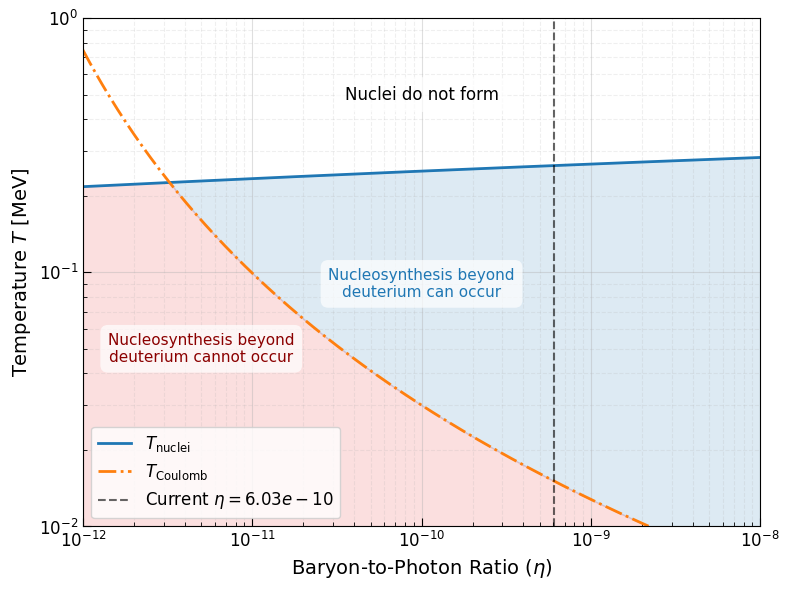

In [4]:
# Plotting Figure 1 from Turner et al. 2021

# Define grid for baryon-to-photon ratio eta
eta_grid = np.linspace(start=1e-12, stop=1e-8, num=100000)
eta10_grid = eta_grid / 1e-10

# Pre-calculate temperatures so we can use them for logic
t_n = T_nuclei(eta10_grid)
t_c = T_coulomb(eta10_grid)

# Create a figure with a standard scientific aspect ratio
plt.figure(figsize=(8, 6))

# Plot the temperatures
plt.loglog(eta_grid, t_n, label=r'$T_{\rm nuclei}$', linewidth=2)
plt.loglog(eta_grid, t_c, label=r'$T_{\rm Coulomb}$', linewidth=2, linestyle='-.')

# 1. SHADE the region where T_nuclei > T_coulomb
plt.fill_between(eta_grid, 
                 t_c, 
                 t_n, 
                 where=(t_n > t_c),
                 interpolate=True,
                 color='C0', alpha=0.15) 

# 2. SHADE the region where T < T_nuclei AND T < T_Coulomb
plt.fill_between(eta_grid, 
                 0.01,                  # Lower bound is the bottom of the plot
                 np.minimum(t_n, t_c),  # Upper bound is the lowest of the two curves
                 color='lightcoral', alpha=0.25)

# --- TEXT LABELS ---

# Text for the middle region (can occur)
plt.text(1e-10, 0.09, 'Nucleosynthesis beyond\ndeuterium can occur', 
         fontsize=11, ha='center', va='center', color='#1f77b4', 
         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.5'))

# Text for the bottom region (cannot occur)
plt.text(0.5e-11, 0.05, 'Nucleosynthesis beyond\ndeuterium cannot occur', 
         fontsize=11, ha='center', va='center', color='darkred', 
         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.5'))

# Text for the top region (nuclei do not form - no shading)
plt.text(1e-10, 0.5, 'Nuclei do not form', 
         fontsize=12, ha='center', va='center', color='black', 
         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.5'))

# Add a vertical line for the current baryon-to-photon ratio
eta_current = 6.03e-10
plt.axvline(x=eta_current, color='black', linestyle='--', alpha=0.6, 
            label=rf'Current $\eta = {eta_current:.2e}$')

# Axis limits and labels
plt.ylim(0.01, 1)
plt.xlim(1e-12, 1e-8)
plt.xlabel(r'Baryon-to-Photon Ratio ($\eta$)', fontsize=14)
plt.ylabel(r'Temperature $T$ [MeV]', fontsize=14)

# Tick parameters for paper-quality
plt.tick_params(axis='both', which='major', labelsize=12, length=6, direction='in')
plt.tick_params(axis='both', which='minor', length=3, direction='in')

# Add grid lines for easier reading on a log-log plot
plt.grid(True, which="major", ls="-", alpha=0.4)
plt.grid(True, which="minor", ls="--", alpha=0.2)

# Legend without an intrusive frame
plt.legend(fontsize=12, frameon=True, loc='lower left')

plt.tight_layout()
plt.show()


2. Glance through Fuller’s review to get a grip of the ingredients of BBN. You will eventually have to plot the top few curves of Figure Fuller will be a good reference for later parts of the project.

    - SarkarLec is yet another source to aid understanding.

3. Lightning review of the history of the universe. 

On a log-log scale, plot the densities of radiation, baryonic matter, dark matter and vacuum energy as a function of inverse scale factor, starting with a value of $R^{-1}=10^{10}$ and ending at $R^{-1} = 1$. Use the current ($R = 1$) values as boundary conditions. Use units of GeV/cm3.

-  What is your best guess for where BBN occurs on this plot?
-  Mark the moment at which atomic recombination + photon decoupling occurs, i.e. the point at which the cosmic microwave background is born. How close is this to the moment of matter-radiation equality? Comment on the significance of this in terms of the initial conditions, in particular the baryon-to-photon ratio.
-  How close is the current epoch to the moment at which the densities of vacuum energy density and matter are equal? What's weird about that? (Hint: extend the curves to the right.) What has this weirdness got to do with the “cosmological constant problem”?


In [5]:
# Defining the evolutions of the energy densities of different components 

## Matter energy density evolution 

def epsilon_m(epsilon_m_0, a):   # inputs: current matter energy density and scale factor
    return epsilon_m_0 * a**(-3) 


# Radiation energy density evolution 

def epsilon_r(epsilon_r_0, a):   # inputs: current radiation energy density and scale factor
    return epsilon_r_0 * a**(-4) 


# Lambda energy density evolution 

def epsilon_de(epsilon_de_0, a):   # inputs: current cosmological constant energy density and scale factor
    return epsilon_de_0 * a**0



In [6]:
# Setting the initial energy densities values 

epsilon_m_0 = Omega_m_0 * Omega_c_0    # current energy density of matter
epsilon_b_0 = Omega_b_0 * Omega_c_0    # current energy density of baryons
epsilon_r_0 = Omega_r_0 * Omega_c_0    # current energy density of radiation
epsilon_de_0 = Omega_de_0 * Omega_c_0  # current energy density of dark energy

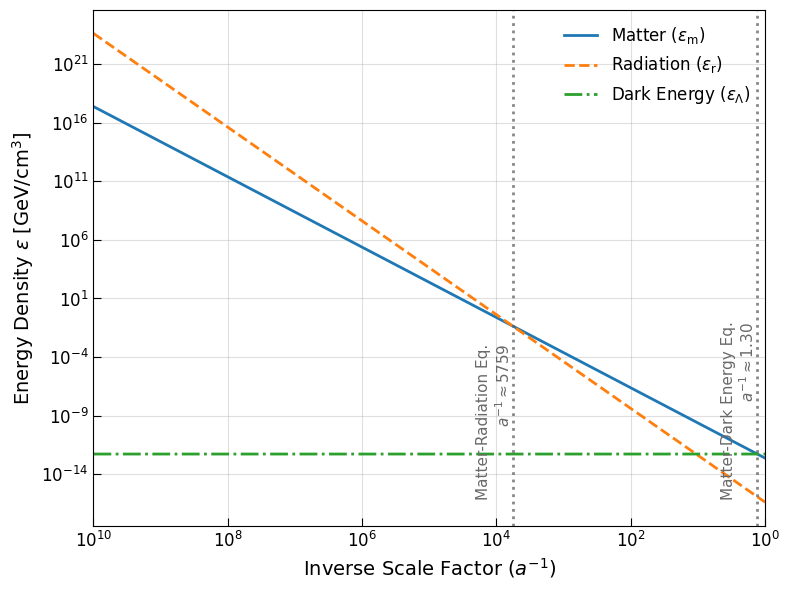

In [10]:
# Plotting the evolution of energy densities as a function of the scale factor

# Define grid for inverse scale factor (a^-1)
a_inv_grid = np.geomspace(start=1e10, stop=1, num=100000)
a_grid = a_inv_grid**(-1)

# Create a figure with a standard scientific aspect ratio
plt.figure(figsize=(8, 6))

# Plot the energy densities
plt.loglog(a_inv_grid, epsilon_m(epsilon_m_0, a_grid), label=r'Matter ($\varepsilon_{\rm m}$)', linewidth=2)
plt.loglog(a_inv_grid, epsilon_r(epsilon_r_0, a_grid), label=r'Radiation ($\varepsilon_{\rm r}$)', linewidth=2, linestyle='--')
plt.loglog(a_inv_grid, epsilon_de(epsilon_de_0, a_grid), label=r'Dark Energy ($\varepsilon_{\rm \Lambda}$)', linewidth=2, linestyle='-.')


# --- ADDING THE EQUALITY CROSSING POINTS ---

# 1. Matter-Radiation Equality
# a_inv_rm =  1 / a_rm
a_inv_rm = Omega_m_0/Omega_r_0
plt.axvline(x=a_inv_rm, color='dimgray', linestyle=':', linewidth=2, alpha=0.8)

# Transform=plt.gca().get_xaxis_transform() allows us to position 'y' relative to the plot height (0 to 1) 
# instead of absolute energy density values, which keeps the text pinned neatly to the bottom
plt.text(a_inv_rm, 0.05, f'Matter-Radiation Eq.\n$a^{{-1}} \\approx {a_inv_rm:.0f}$ ', 
         transform=plt.gca().get_xaxis_transform(),
         fontsize=11, color='dimgray', rotation=90, ha='right', va='bottom')

# 2. Matter-Dark Energy Equality
a_inv_ml = 1 / a_ml
plt.axvline(x=a_inv_ml, color='dimgray', linestyle=':', linewidth=2, alpha=0.8)

plt.text(a_inv_ml, 0.05, f'Matter-Dark Energy Eq.\n$a^{{-1}} \\approx {a_inv_ml:.2f}$ ', 
         transform=plt.gca().get_xaxis_transform(),
         fontsize=11, color='dimgray', rotation=90, ha='right', va='bottom')


# Reverse the x-axis (from 10^10 down to 1)
plt.xlim(1e10, 1)

# Axis labels
plt.xlabel(r'Inverse Scale Factor ($a^{-1}$)', fontsize=14)
plt.ylabel(r'Energy Density $\varepsilon$ [GeV/cm$^3$]', fontsize=14)

# Tick parameters for paper-quality
plt.tick_params(axis='both', which='major', labelsize=12, length=6, direction='in')
plt.tick_params(axis='both', which='minor', length=3, direction='in')

# Add grid lines for easier reading on a log-log plot
plt.grid(True, which="major", ls="-", alpha=0.4)
plt.grid(True, which="minor", ls="--", alpha=0.2)

# Legend without an intrusive frame
plt.legend(fontsize=12, frameon=False)

plt.tight_layout()
plt.show()
